In [1]:
import cv2
import numpy as np
import pickle
import glob
import os
import matplotlib.pyplot as plt
import datetime

# Use the same capture system as complete_attack.ipynb
from capture_utils import *

Pixel format set to RGB8
IC4 Grabber and Sink initialized.


## Configuration
Set your checkerboard dimensions and square size here.

✓ Checkerboard pattern saved to: checkerboard_pattern_10x7.png
  Pattern: 10x7 squares (9x6 inner corners)
  Square size: 100 pixels

📋 PRINT INSTRUCTIONS:
  1. Print this image at 100% scale (no scaling)
  2. Measure one square and update SQUARE_SIZE in the config cell
  3. Mount on a flat, rigid surface


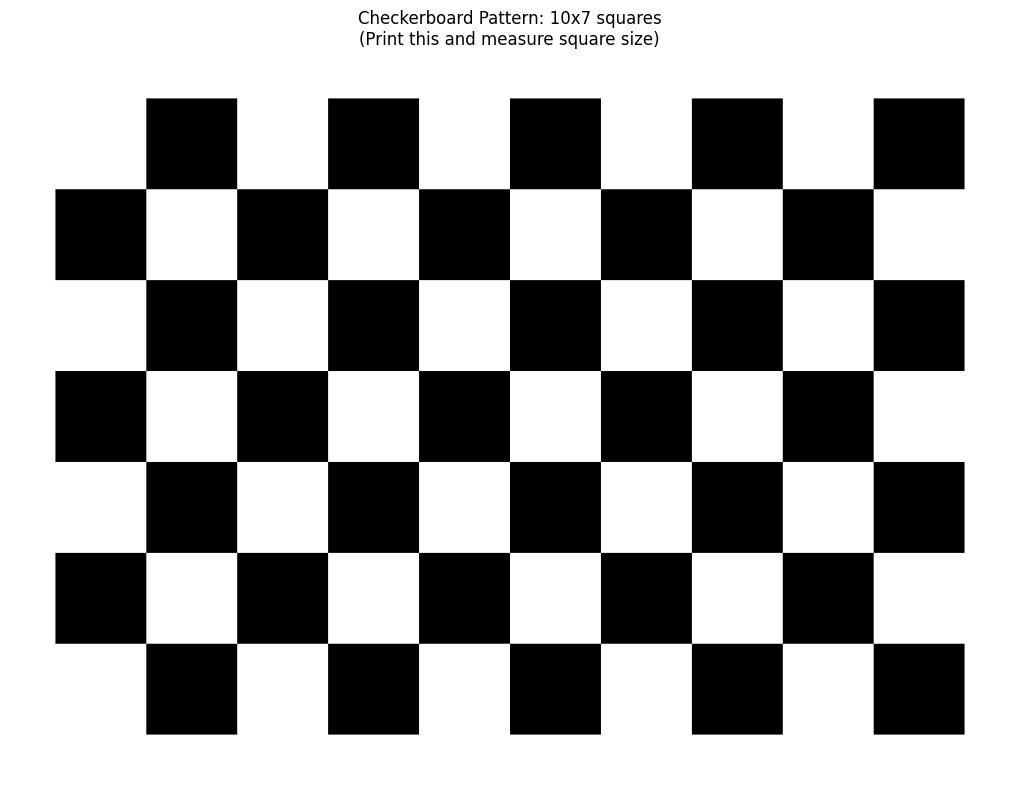

In [9]:
# Generate and save a checkerboard pattern to print
def generate_checkerboard(rows, cols, square_size_px=100):
    """
    Generate a checkerboard pattern image for printing.
    
    Args:
        rows: number of rows of squares (not inner corners)
        cols: number of columns of squares (not inner corners)
        square_size_px: size of each square in pixels
    """
    # Create checkerboard
    board_height = rows * square_size_px
    board_width = cols * square_size_px
    
    checkerboard = np.zeros((board_height, board_width), dtype=np.uint8)
    
    for i in range(rows):
        for j in range(cols):
            if (i + j) % 2 == 0:
                y1 = i * square_size_px
                y2 = (i + 1) * square_size_px
                x1 = j * square_size_px
                x2 = (j + 1) * square_size_px
                checkerboard[y1:y2, x1:x2] = 255
    
    return checkerboard

# Generate pattern with one more row/col than inner corners
# For 9x6 inner corners, we need a 10x7 checkerboard
pattern_rows = 7  # CHECKERBOARD_SIZE[1] + 1
pattern_cols = 10  # CHECKERBOARD_SIZE[0] + 1
square_size_px = 100  # 100px per square - adjust for print size

checkerboard = generate_checkerboard(pattern_rows, pattern_cols, square_size_px)

# Add white border for easier detection
border = 50
checkerboard_bordered = cv2.copyMakeBorder(
    checkerboard, border, border, border, border, 
    cv2.BORDER_CONSTANT, value=255
)

# Save the pattern
pattern_path = "checkerboard_pattern_10x7.png"
cv2.imwrite(pattern_path, checkerboard_bordered)

print(f"✓ Checkerboard pattern saved to: {pattern_path}")
print(f"  Pattern: {pattern_cols}x{pattern_rows} squares ({pattern_cols-1}x{pattern_rows-1} inner corners)")
print(f"  Square size: {square_size_px} pixels")
print(f"\n📋 PRINT INSTRUCTIONS:")
print(f"  1. Print this image at 100% scale (no scaling)")
print(f"  2. Measure one square and update SQUARE_SIZE in the config cell")
print(f"  3. Mount on a flat, rigid surface")

# Display
plt.figure(figsize=(12, 8))
plt.imshow(checkerboard_bordered, cmap='gray')
plt.title(f"Checkerboard Pattern: {pattern_cols}x{pattern_rows} squares\n(Print this and measure square size)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
OUTPUT_PATH = r"C:\git\PhysicalAdverserialProj\calibration.pkl"


In [ ]:
# Checkerboard configuration
# Number of INNER corners (not squares!)
# For a 9x6 checkerboard pattern, use (8, 5) inner corners
CHECKERBOARD_SIZE = (9, 6)  # (columns, rows) of inner corners

# Size of each square in meters (or any consistent unit)
SQUARE_SIZE = 0.025  # 2.5 cm squares

# Output path for calibration file
# Directory to save/load calibration images
CALIB_IMAGES_DIR = "calibration_images"
os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)

print(f"Checkerboard inner corners: {CHECKERBOARD_SIZE}")
print(f"Square size: {SQUARE_SIZE * 100} cm")
print(f"Output path: {OUTPUT_PATH}")

Checkerboard inner corners: (9, 6)
Square size: 2.5 cm
Output path: C:\git\wall_alignment\calibration.pkl


## Option 1: Capture Calibration Images from Camera
Run this cell to capture images interactively from your camera.

In [4]:
# Capture calibration images from camera using capture_utils system
# Press 's' to save an image, 'q' to quit

# cap is already available from capture_utils import

saved_count = len(glob.glob(f"{CALIB_IMAGES_DIR}/*.png"))
print(f"Starting capture. Already have {saved_count} images.")
print("Press 's' to save image when checkerboard is detected")
print("Press 'q' to quit")
print("Recommended: Capture 15-25 images from different angles/positions")

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    display = frame.copy()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Try to find checkerboard
    found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD_SIZE, 
                                                cv2.CALIB_CB_ADAPTIVE_THRESH + 
                                                cv2.CALIB_CB_NORMALIZE_IMAGE)
    
    if found:
        # Refine corners
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        cv2.drawChessboardCorners(display, CHECKERBOARD_SIZE, corners_refined, found)
        cv2.putText(display, "CHECKERBOARD FOUND - Press 's' to save", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    else:
        cv2.putText(display, "Checkerboard not detected", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    cv2.putText(display, f"Saved: {saved_count} images", (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    
    cv2.imshow('Camera Calibration', display)
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('s') and found:
        filename = f"{CALIB_IMAGES_DIR}/calib_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{saved_count}.png"
        cv2.imwrite(filename, frame)
        saved_count += 1
        print(f"Saved: {filename}")
    elif key == ord('q'):
        break

cv2.destroyAllWindows()
print(f"\nCapture complete. Total images: {saved_count}")

Starting capture. Already have 0 images.
Press 's' to save image when checkerboard is detected
Press 'q' to quit
Recommended: Capture 15-25 images from different angles/positions
Saved: calibration_images/calib_20251224_200933_0.png
Saved: calibration_images/calib_20251224_200937_1.png
Saved: calibration_images/calib_20251224_200940_2.png
Saved: calibration_images/calib_20251224_200942_3.png
Saved: calibration_images/calib_20251224_200945_4.png
Saved: calibration_images/calib_20251224_200946_5.png
Saved: calibration_images/calib_20251224_200948_6.png
Saved: calibration_images/calib_20251224_200949_7.png
Saved: calibration_images/calib_20251224_200952_8.png
Saved: calibration_images/calib_20251224_200958_9.png
Saved: calibration_images/calib_20251224_201004_10.png
Saved: calibration_images/calib_20251224_201006_11.png
Saved: calibration_images/calib_20251224_201008_12.png
Saved: calibration_images/calib_20251224_201011_13.png
Saved: calibration_images/calib_20251224_201013_14.png
Saved:

## Option 2: Load Existing Calibration Images
Skip the capture step if you already have calibration images.

In [ ]:
# List available calibration images
image_files = glob.glob(f"{CALIB_IMAGES_DIR}/*.png") + glob.glob(f"{CALIB_IMAGES_DIR}/*.jpg")
print(f"Found {len(image_files)} calibration images:")
for f in image_files:
    print(f"  - {f}")

## Perform Camera Calibration

In [5]:
# Prepare object points (3D points in real world space)
objp = np.zeros((CHECKERBOARD_SIZE[0] * CHECKERBOARD_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD_SIZE[0], 0:CHECKERBOARD_SIZE[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

# Arrays to store object points and image points
obj_points = []  # 3D points in real world
img_points = []  # 2D points in image plane
used_images = []

# Termination criteria for corner refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Process each calibration image
image_files = glob.glob(f"{CALIB_IMAGES_DIR}/*.png") + glob.glob(f"{CALIB_IMAGES_DIR}/*.jpg")

print(f"Processing {len(image_files)} images...\n")

for fname in image_files:
    img = cv2.imread(fname)
    if img is None:
        print(f"  [SKIP] Could not read: {fname}")
        continue
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Find checkerboard corners
    found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD_SIZE,
                                                cv2.CALIB_CB_ADAPTIVE_THRESH +
                                                cv2.CALIB_CB_NORMALIZE_IMAGE)
    
    if found:
        # Refine corner locations
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        
        obj_points.append(objp)
        img_points.append(corners_refined)
        used_images.append(fname)
        print(f"  [OK] {os.path.basename(fname)}")
    else:
        print(f"  [FAIL] Checkerboard not found: {os.path.basename(fname)}")

print(f"\nSuccessfully processed {len(obj_points)} / {len(image_files)} images")

if len(obj_points) < 5:
    print("\n⚠️  WARNING: Need at least 5 valid images for good calibration!")

Processing 45 images...

  [OK] calib_20251224_200933_0.png
  [OK] calib_20251224_200937_1.png
  [OK] calib_20251224_200940_2.png
  [OK] calib_20251224_200942_3.png
  [OK] calib_20251224_200945_4.png
  [OK] calib_20251224_200946_5.png
  [OK] calib_20251224_200948_6.png
  [OK] calib_20251224_200949_7.png
  [OK] calib_20251224_200952_8.png
  [OK] calib_20251224_200958_9.png
  [OK] calib_20251224_201004_10.png
  [OK] calib_20251224_201006_11.png
  [OK] calib_20251224_201008_12.png
  [OK] calib_20251224_201011_13.png
  [OK] calib_20251224_201013_14.png
  [OK] calib_20251224_201016_15.png
  [OK] calib_20251224_201017_16.png
  [OK] calib_20251224_201018_17.png
  [OK] calib_20251224_201019_18.png
  [OK] calib_20251224_201024_19.png
  [OK] calib_20251224_201027_20.png
  [OK] calib_20251224_201028_21.png
  [OK] calib_20251224_201029_22.png
  [OK] calib_20251224_201030_23.png
  [OK] calib_20251224_201031_24.png
  [OK] calib_20251224_201032_25.png
  [OK] calib_20251224_201033_26.png
  [OK] calib_

In [6]:
# Perform calibration
if len(obj_points) >= 3:
    # Get image size from first image
    sample_img = cv2.imread(used_images[0])
    img_size = (sample_img.shape[1], sample_img.shape[0])
    
    print(f"Image size: {img_size}")
    print("\nCalibrating camera...")
    
    # Calibrate
    ret, cameraMatrix, dist, rvecs, tvecs = cv2.calibrateCamera(
        obj_points, img_points, img_size, None, None
    )
    
    print(f"\n{'='*60}")
    print("CALIBRATION RESULTS")
    print(f"{'='*60}")
    print(f"\nReprojection error (RMS): {ret:.4f} pixels")
    print(f"  (Good calibration typically has RMS < 0.5)")
    
    print(f"\nCamera Matrix:\n{cameraMatrix}")
    print(f"\nFocal lengths:")
    print(f"  fx = {cameraMatrix[0,0]:.2f} pixels")
    print(f"  fy = {cameraMatrix[1,1]:.2f} pixels")
    print(f"\nPrincipal point:")
    print(f"  cx = {cameraMatrix[0,2]:.2f} pixels")
    print(f"  cy = {cameraMatrix[1,2]:.2f} pixels")
    
    print(f"\nDistortion Coefficients:")
    print(f"  k1 = {dist[0,0]:.6f}")
    print(f"  k2 = {dist[0,1]:.6f}")
    print(f"  p1 = {dist[0,2]:.6f}")
    print(f"  p2 = {dist[0,3]:.6f}")
    print(f"  k3 = {dist[0,4]:.6f}")
else:
    print("❌ Not enough valid images for calibration!")

Image size: (640, 480)

Calibrating camera...

CALIBRATION RESULTS

Reprojection error (RMS): 1.5422 pixels
  (Good calibration typically has RMS < 0.5)

Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Focal lengths:
  fx = 1047.40 pixels
  fy = 950.49 pixels

Principal point:
  cx = 324.04 pixels
  cy = 323.90 pixels

Distortion Coefficients:
  k1 = 0.260138
  k2 = -4.378714
  p1 = 0.035637
  p2 = -0.002583
  k3 = 22.197071


## Visualize Calibration Quality

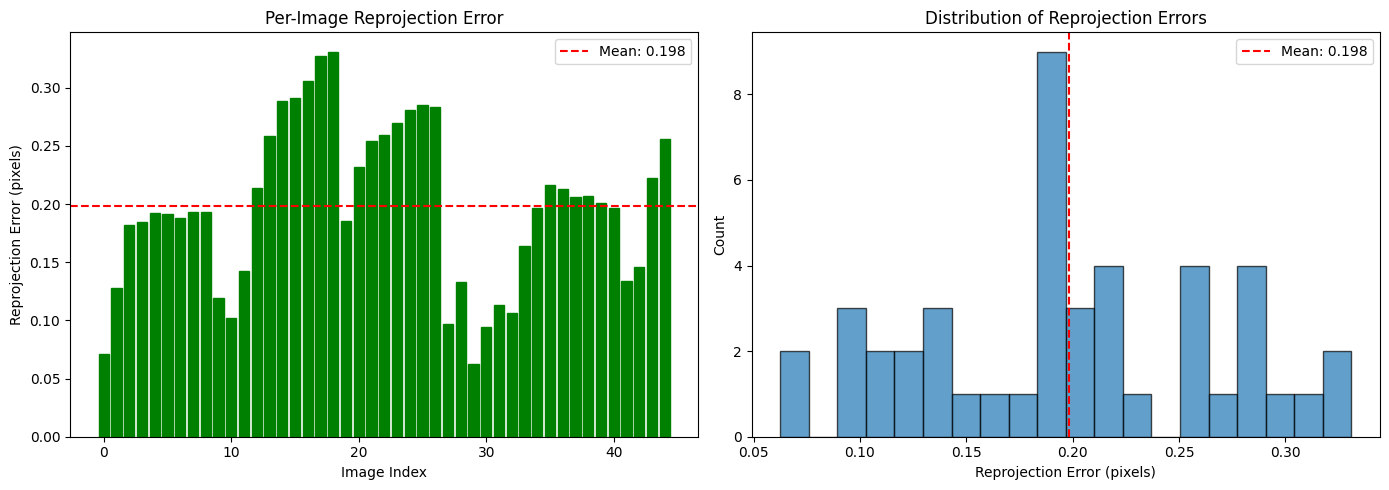


Per-image errors:
  ✓ Image 0: 0.0707 px - calib_20251224_200933_0.png
  ✓ Image 1: 0.1279 px - calib_20251224_200937_1.png
  ✓ Image 2: 0.1824 px - calib_20251224_200940_2.png
  ✓ Image 3: 0.1845 px - calib_20251224_200942_3.png
  ✓ Image 4: 0.1923 px - calib_20251224_200945_4.png
  ✓ Image 5: 0.1912 px - calib_20251224_200946_5.png
  ✓ Image 6: 0.1884 px - calib_20251224_200948_6.png
  ✓ Image 7: 0.1931 px - calib_20251224_200949_7.png
  ✓ Image 8: 0.1928 px - calib_20251224_200952_8.png
  ✓ Image 9: 0.1197 px - calib_20251224_200958_9.png
  ✓ Image 10: 0.1025 px - calib_20251224_201004_10.png
  ✓ Image 11: 0.1422 px - calib_20251224_201006_11.png
  ✓ Image 12: 0.2134 px - calib_20251224_201008_12.png
  ✓ Image 13: 0.2584 px - calib_20251224_201011_13.png
  ✓ Image 14: 0.2890 px - calib_20251224_201013_14.png
  ✓ Image 15: 0.2915 px - calib_20251224_201016_15.png
  ✓ Image 16: 0.3062 px - calib_20251224_201017_16.png
  ✓ Image 17: 0.3274 px - calib_20251224_201018_17.png
  ✓ Image 1

In [7]:
# Calculate per-image reprojection errors
errors = []
for i in range(len(obj_points)):
    img_points_reproj, _ = cv2.projectPoints(obj_points[i], rvecs[i], tvecs[i], cameraMatrix, dist)
    error = cv2.norm(img_points[i], img_points_reproj, cv2.NORM_L2) / len(img_points_reproj)
    errors.append(error)

# Plot reprojection errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of per-image errors
ax = axes[0]
bars = ax.bar(range(len(errors)), errors)
ax.axhline(y=np.mean(errors), color='r', linestyle='--', label=f'Mean: {np.mean(errors):.3f}')
ax.set_xlabel('Image Index')
ax.set_ylabel('Reprojection Error (pixels)')
ax.set_title('Per-Image Reprojection Error')
ax.legend()

# Color bars by error magnitude
for i, (bar, err) in enumerate(zip(bars, errors)):
    if err > 1.0:
        bar.set_color('red')
    elif err > 0.5:
        bar.set_color('orange')
    else:
        bar.set_color('green')

# Histogram of errors
ax = axes[1]
ax.hist(errors, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=np.mean(errors), color='r', linestyle='--', label=f'Mean: {np.mean(errors):.3f}')
ax.set_xlabel('Reprojection Error (pixels)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Reprojection Errors')
ax.legend()

plt.tight_layout()
plt.show()

# Flag problematic images
print("\nPer-image errors:")
for i, (err, fname) in enumerate(zip(errors, used_images)):
    status = "✓" if err < 0.5 else "⚠" if err < 1.0 else "❌"
    print(f"  {status} Image {i}: {err:.4f} px - {os.path.basename(fname)}")

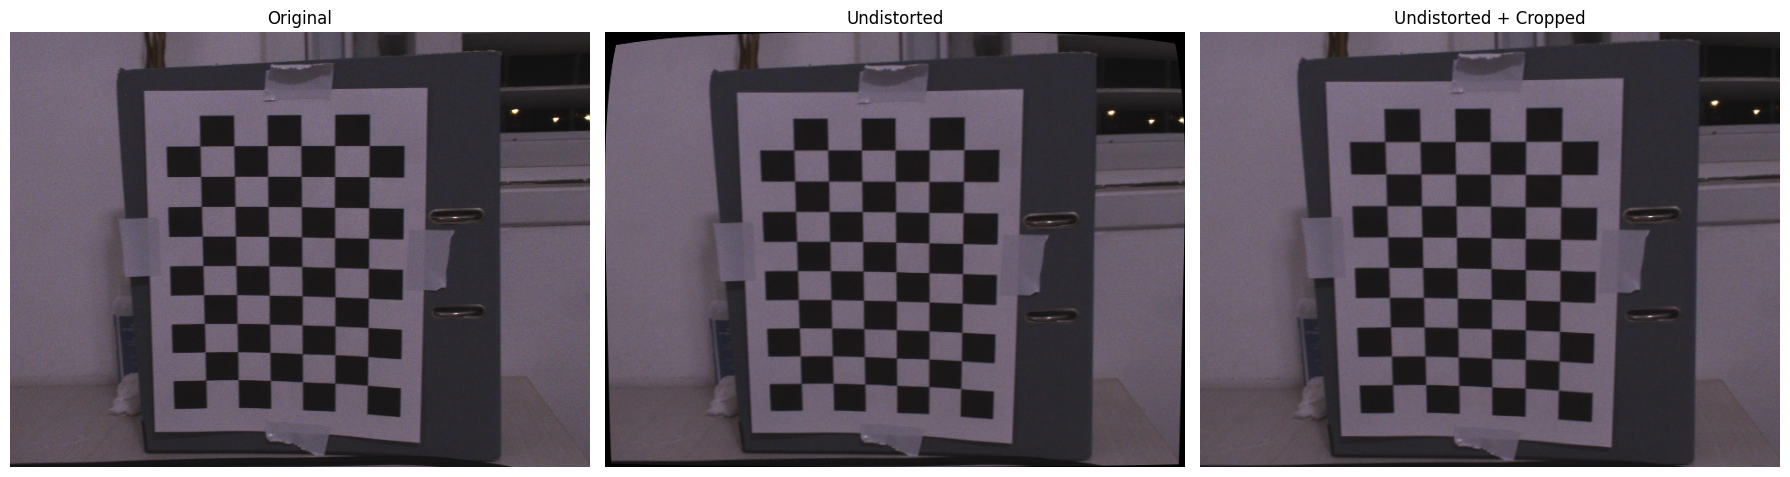

In [8]:
# Visualize undistortion on a sample image
sample_img = cv2.imread(used_images[0])

# Get optimal new camera matrix
h, w = sample_img.shape[:2]
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(cameraMatrix, dist, (w, h), 1, (w, h))

# Undistort
undistorted = cv2.undistort(sample_img, cameraMatrix, dist, None, new_camera_matrix)

# Crop to ROI
x, y, w_roi, h_roi = roi
if w_roi > 0 and h_roi > 0:
    undistorted_cropped = undistorted[y:y+h_roi, x:x+w_roi]
else:
    undistorted_cropped = undistorted

# Display
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
axes[1].set_title('Undistorted')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(undistorted_cropped, cv2.COLOR_BGR2RGB))
axes[2].set_title('Undistorted + Cropped')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Save Calibration

In [13]:
# Save calibration to pickle file
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with open(OUTPUT_PATH, 'wb') as f:
    pickle.dump((cameraMatrix, dist), f)

print(f"✓ Calibration saved to: {OUTPUT_PATH}")
print(f"\nTo load:")
print(f"  import pickle")
print(f"  cameraMatrix, dist = pickle.load(open(r'{OUTPUT_PATH}', 'rb'))")

✓ Calibration saved to: C:\git\PhysicalAdverserialProj\calibration.pkl

To load:
  import pickle
  cameraMatrix, dist = pickle.load(open(r'C:\git\PhysicalAdverserialProj\calibration.pkl', 'rb'))


In [14]:
# Also save extended calibration data (optional)
extended_path = OUTPUT_PATH.replace('.pkl', '_extended.pkl')

calibration_data = {
    'cameraMatrix': cameraMatrix,
    'dist': dist,
    'rvecs': rvecs,
    'tvecs': tvecs,
    'rms_error': ret,
    'image_size': img_size,
    'checkerboard_size': CHECKERBOARD_SIZE,
    'square_size': SQUARE_SIZE,
    'n_images': len(obj_points),
    'per_image_errors': errors,
    'calibration_date': datetime.datetime.now().isoformat()
}

with open(extended_path, 'wb') as f:
    pickle.dump(calibration_data, f)

print(f"✓ Extended calibration data saved to: {extended_path}")

✓ Extended calibration data saved to: C:\git\PhysicalAdverserialProj\calibration_extended.pkl


## Verify Saved Calibration

In [15]:
# Verify by loading and displaying
loaded_matrix, loaded_dist = pickle.load(open(OUTPUT_PATH, 'rb'))

print("Loaded Camera Matrix:")
print(loaded_matrix)
print(f"\nLoaded Distortion Coefficients: {loaded_dist.flatten()}")

# Verify match
if np.allclose(loaded_matrix, cameraMatrix) and np.allclose(loaded_dist, dist):
    print("\n✓ Verification passed - saved and loaded values match!")
else:
    print("\n❌ Verification failed - values don't match!")

Loaded Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Loaded Distortion Coefficients: [ 2.60138074e-01 -4.37871352e+00  3.56370583e-02 -2.58297180e-03
  2.21970709e+01]

✓ Verification passed - saved and loaded values match!
